# 04 午高峰骑手运力优先级与离线策略回放

决策问题：在午高峰派单时点和给定增量运力预算约束下，应优先将可调度运力配置至哪些匿名空间网格？

本 Notebook 报告策略覆盖与后验识别结果，不估计真实减少的超时订单数。

## 管理摘要

- 跨期回放覆盖 2022-10-23 和 10-24 的 **6 个午高峰快照**，共 **3,854 个待派订单**，其中后验超时 **752 单**。
- **78.07%** 的待派订单符合早期风险模型的样本定义；其余预订单或未知商圈订单回退到历史网格平滑超时率。
- 以每时点 30 个增量运力槽位为例，风险加权策略覆盖 **10.07%** 的等待订单、**11.82%** 的预期超时风险，后验覆盖 **11.70%** 的实际超时订单。
- 逐快照比较中，风险加权策略相对供需量基线为 **4 胜、1 平、1 负**；汇总优势尚不能证明策略在不同日期和峰值条件下稳定占优。
- 同一预算下，风险加权策略的槽位加权后验超时率为 **26.57%**，供需量基线为 **14.23%**，表明前者提高了高风险网格的识别集中度；该差异不代表配置后超时率下降 12.34 个百分点。
- 单网格配置占比受 25% 护栏约束；由于整数向上取整，30 槽位情景的实际最高占比为 **26.67%**。
- 结果只支持“优先试点这些网格”的决策，不支持直接承诺线上收益。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUT = PROJECT_ROOT / "outputs" / "capacity"
snapshot = pd.read_parquet(OUT / "snapshot_grid_metrics.parquet")
allocations = pd.read_parquet(OUT / "rider_slot_allocations.parquet")
summary = pd.read_csv(OUT / "scenario_summary.csv")
snapshot_policy = pd.read_csv(OUT / "snapshot_policy_metrics.csv")
snapshot_profile = pd.read_csv(OUT / "snapshot_profile.csv")

print(f"epochs={snapshot[['dt', 'dispatch_time']].drop_duplicates().shape[0]}")
print(f"waiting_orders={snapshot['waiting_orders'].sum():,}")
print(f"model_scored_share={snapshot['model_scored_orders'].sum() / snapshot['waiting_orders'].sum():.2%}")
snapshot_profile

epochs=6
waiting_orders=3,854
model_scored_share=78.07%


,dt,dispatch_time,dispatch_time_local,waiting_orders,model_scored_orders,demand_grids,actual_late_orders,mean_candidates_within_2km,mean_idle_candidates_within_2km
0,20221023,1666495519,2022-10-23 11:25:19,634,497,179,114,338.0838,99.8771
1,20221023,1666495639,2022-10-23 11:27:19,591,469,186,104,322.4892,93.6344
2,20221023,1666495819,2022-10-23 11:30:19,669,522,184,100,326.9076,91.2011
3,20221024,1666581917,2022-10-24 11:25:17,650,498,176,149,349.2557,106.9886
4,20221024,1666582037,2022-10-24 11:27:17,702,539,189,159,356.2487,110.7090
5,20221024,1666582217,2022-10-24 11:30:17,608,484,179,126,345.5922,102.2793


## 1. 策略口径与约束条件

- 500m × 400m 网格，订单按商家位置落网格；
- 候选供给为网格中心 2km 内候选骑手数；
- 相邻网格邻域重叠，同一骑手可能被多次计入，因此该指标不可跨网格求和；
- 订单风险优先使用 10 月 17–22 日训练的进入配送时模型，不适用订单回退到历史网格风险；
- 每个网格最多获得预算的 25%（向上取整）。

预测概率之和仅作为相对风险质量参与排序。由于模型未经过独立的长期概率校准，不将该值解释为超时订单绝对预测数。

## 2. 派单快照的空间供需与风险分布

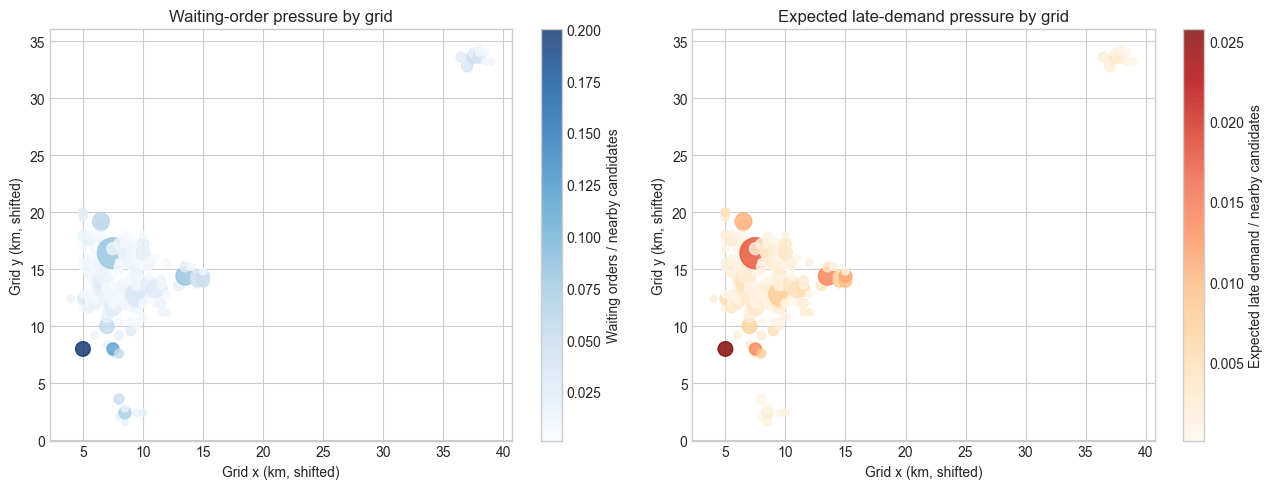

In [2]:
first_key = snapshot[["dt", "dispatch_time"]].sort_values(["dt", "dispatch_time"]).iloc[0]
first = snapshot.loc[
    snapshot["dt"].eq(first_key["dt"])
    & snapshot["dispatch_time"].eq(first_key["dispatch_time"])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter1 = axes[0].scatter(
    first["grid_x"] * 0.5,
    first["grid_y"] * 0.4,
    s=15 + first["waiting_orders"] * 12,
    c=first["waiting_orders_per_candidate_2km"],
    cmap="Blues",
    alpha=0.8,
)
axes[0].set_title("Waiting-order pressure by grid")
axes[0].set_xlabel("Grid x (km, shifted)")
axes[0].set_ylabel("Grid y (km, shifted)")
fig.colorbar(scatter1, ax=axes[0], label="Waiting orders / nearby candidates")

scatter2 = axes[1].scatter(
    first["grid_x"] * 0.5,
    first["grid_y"] * 0.4,
    s=15 + first["waiting_orders"] * 12,
    c=first["risk_pressure"],
    cmap="OrRd",
    alpha=0.8,
)
axes[1].set_title("Expected late-demand pressure by grid")
axes[1].set_xlabel("Grid x (km, shifted)")
axes[1].set_ylabel("Grid y (km, shifted)")
fig.colorbar(scatter2, ax=axes[1], label="Expected late demand / nearby candidates")
plt.tight_layout()
plt.show()

坐标是脱敏后的相对位置，图形用于比较空间结构，不能恢复真实商圈。点大小代表等待订单数，颜色分别代表订单供给压力和风险调整压力。

## 3. 预算敏感性与策略基准比较

In [3]:
summary

,budget_rider_slots_per_epoch,policy,epochs,total_allocated_rider_slots,targeted_grid_count_sum,waiting_order_coverage_pct,expected_late_risk_coverage_pct,actual_late_order_coverage_pct_hindsight,allocation_weighted_expected_late_rate_pct,allocation_weighted_actual_late_rate_pct_hindsight,mean_max_single_grid_allocation_share_pct
0,10,risk_adjusted,6,60,24,9.3409,10.8031,11.3032,19.6117,28.2811,30.0000
1,10,volume_only,6,60,24,9.1074,8.9762,9.0426,12.1770,11.8328,30.0000
2,20,risk_adjusted,6,120,26,10.0675,11.8225,11.7021,19.3943,26.3315,25.0000
3,20,volume_only,6,120,24,9.1074,8.9762,9.0426,12.5712,14.2313,25.0000
4,30,risk_adjusted,6,180,26,10.0675,11.8225,11.7021,19.6020,26.5671,26.6667
5,30,volume_only,6,180,25,9.1334,9.0069,9.1755,12.5050,14.2331,26.6667
6,50,risk_adjusted,6,300,28,10.8459,12.7244,12.1011,19.6070,26.0645,26.0000
7,50,volume_only,6,300,27,10.2491,10.0204,10.2394,12.6057,14.4206,26.0000


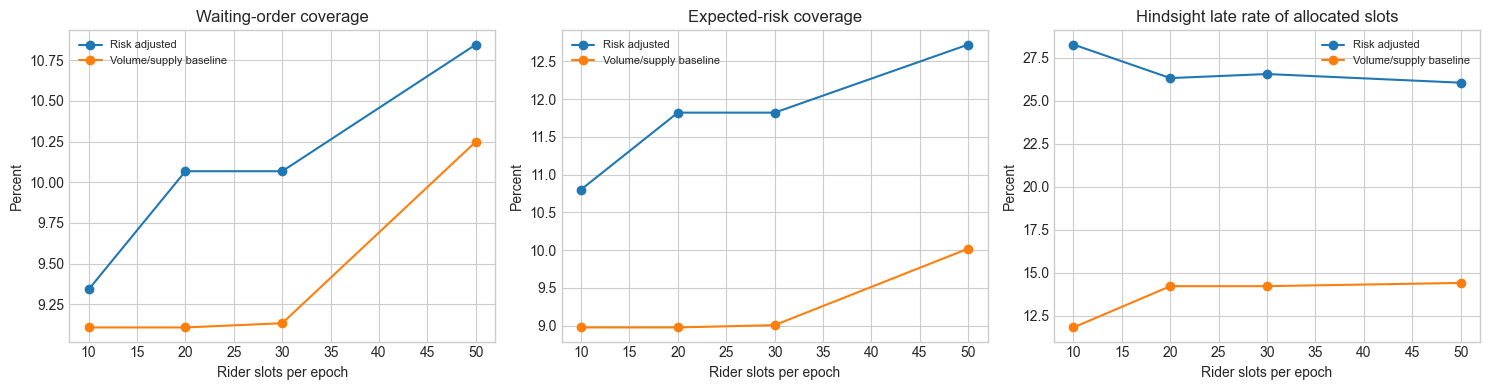

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for policy, group in summary.groupby("policy"):
    label = "Risk adjusted" if policy == "risk_adjusted" else "Volume/supply baseline"
    axes[0].plot(
        group["budget_rider_slots_per_epoch"], group["waiting_order_coverage_pct"],
        marker="o", label=label
    )
    axes[1].plot(
        group["budget_rider_slots_per_epoch"], group["expected_late_risk_coverage_pct"],
        marker="o", label=label
    )
    axes[2].plot(
        group["budget_rider_slots_per_epoch"],
        group["allocation_weighted_actual_late_rate_pct_hindsight"],
        marker="o", label=label
    )
axes[0].set_title("Waiting-order coverage")
axes[1].set_title("Expected-risk coverage")
axes[2].set_title("Hindsight late rate of allocated slots")
for ax in axes:
    ax.set_xlabel("Rider slots per epoch")
    ax.set_ylabel("Percent")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

风险加权策略以部分订单量覆盖为代价，提高了所选网格的风险密度。后验超时率仅用于检验目标区域识别集中度，不是策略增量效果；若运力干预有效，线上实施后的实际超时率应通过对照设计单独评估。

## 4. 30 槽位预算下的逐快照稳定性

In [5]:
snapshot_30 = snapshot_policy.loc[
    snapshot_policy["budget_rider_slots"].eq(30),
    ["dispatch_time_local", "policy", "actual_late_order_coverage_pct_hindsight"],
].copy()
snapshot_30["dispatch_time_local"] = pd.to_datetime(snapshot_30["dispatch_time_local"])
snapshot_comparison = snapshot_30.pivot(
    index="dispatch_time_local",
    columns="policy",
    values="actual_late_order_coverage_pct_hindsight",
).sort_index()
snapshot_comparison["risk_minus_baseline_pct_point"] = (
    snapshot_comparison["risk_adjusted"] - snapshot_comparison["volume_only"]
)
snapshot_comparison

policy,risk_adjusted,volume_only,risk_minus_baseline_pct_point
dispatch_time_local,,,
2022-10-23 11:25:19,18.4211,18.4211,0.0000
2022-10-23 11:27:19,9.6154,5.7692,3.8462
2022-10-23 11:30:19,11.0000,5.0000,6.0000
2022-10-24 11:25:17,14.7651,15.4362,-0.6711
2022-10-24 11:27:17,7.5472,6.2893,1.2579
2022-10-24 11:30:17,9.5238,3.1746,6.3492


风险加权策略在六个快照中取得 4 胜、1 平、1 负，说明汇总结果掩盖了单时点差异。该结果足以支持小规模试点，但不足以宣称策略已经具备稳定收益。

## 5. 30 槽位预算下的单时点配置示例

In [6]:
example = allocations.loc[
    allocations["dt"].eq(first_key["dt"])
    & allocations["dispatch_time"].eq(first_key["dispatch_time"])
    & allocations["budget_rider_slots"].eq(30)
    & allocations["policy"].eq("risk_adjusted")
].copy()

example[
    [
        "grid_x", "grid_y", "waiting_orders", "model_scored_orders",
        "candidate_riders_within_2km", "idle_candidate_riders_within_2km",
        "smoothed_historical_late_rate", "expected_late_demand",
        "actual_late_orders", "allocated_rider_slots",
    ]
].sort_values("allocated_rider_slots", ascending=False)

,grid_x,grid_y,waiting_orders,model_scored_orders,candidate_riders_within_2km,idle_candidate_riders_within_2km,smoothed_historical_late_rate,expected_late_demand,actual_late_orders,allocated_rider_slots
16,10,20,8,8,40,13,0.1236,1.0550,1,8
18,15,41,40,40,506,128,0.2085,8.6935,16,8
19,27,36,13,13,160,66,0.1845,2.2339,4,8
17,15,20,5,3,45,9,0.1765,0.6234,0,6


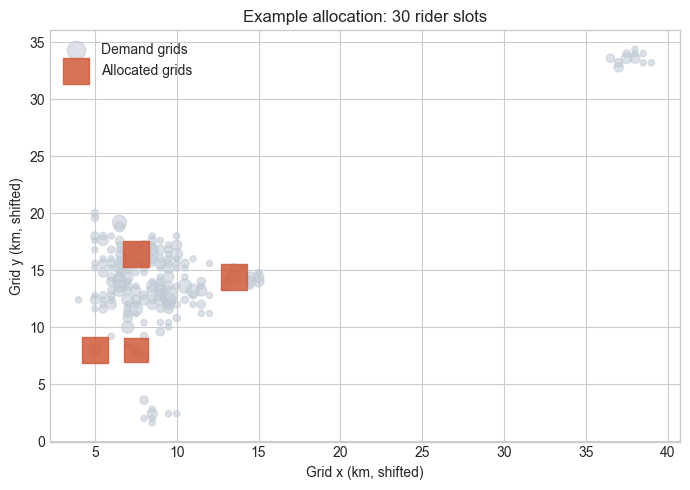

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    first["grid_x"] * 0.5, first["grid_y"] * 0.4,
    s=12 + first["waiting_orders"] * 8, c="#BFC9D4", alpha=0.55, label="Demand grids"
)
ax.scatter(
    example["grid_x"] * 0.5, example["grid_y"] * 0.4,
    s=80 + example["allocated_rider_slots"] * 35,
    c="#D05A3A", marker="s", alpha=0.85, label="Allocated grids"
)
ax.set_title("Example allocation: 30 rider slots")
ax.set_xlabel("Grid x (km, shifted)")
ax.set_ylabel("Grid y (km, shifted)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 策略结论、适用边界与试点方案

**可以支持的决策：** 在 6 个跨期午高峰快照中，风险加权规则相较供需量基线提高了后验高风险网格的识别集中度，可作为小规模运营试点的候选优先级规则。

**不能支持的结论：** 无法从历史快照推断投入 30 个增量运力槽位能够减少多少超时，也无法确认 2km 是最优服务半径。

**建议的线上试点设计：**

1. 在相似商圈时段做分层随机或轮换试点；
2. 明确增量骑手工时、到岗率和实际调动距离；
3. 主指标看准时率和超时订单数，护栏看其他网格准时率、骑手负载、空驶距离和取消率；
4. 至少覆盖多个星期和天气条件，再评估是否扩大。

## Sources

- `outputs/capacity/snapshot_grid_metrics.parquet`
- `outputs/capacity/rider_slot_allocations.parquet`
- `outputs/capacity/scenario_summary.csv`
- `outputs/capacity/snapshot_policy_metrics.csv`
- `docs/07_capacity_scenario.md`
- `scripts/build_capacity_scenario.py`